# PyCatan Tutorial 5

In [30]:
from pathlib import Path
import sys, os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from IPython import get_ipython

# Add the repository 'src' directory to sys.path by searching upward from the current working directory
repo_root = Path.cwd()
for _ in range(6):
    if (repo_root / 'src').exists():
        break
    if repo_root.parent == repo_root:
        break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

try:
    import Py_Catan_AI as pc
except Exception as e:
    raise ImportError(
        "Failed to import `Py_Catan_AI`. Make sure you are running this notebook from the repository root "
        "or that the project's `src/` folder is available on sys.path. I tried to add: " + str(repo_root / 'src')
    ) from e

import boto3
from keras.models import load_model
from keras.optimizers import Adam

# IPython helper
ip = get_ipython()

In [31]:
# Set working directory to repo root
os.chdir(pc.get_repo_root(target_name="PyCatan"))

# Determine if running in Jupyter Notebook or as a script and load args accordingly
if get_ipython():
    print("Running in Jupyter Notebook")
    args = pc.Args()
else:
    print("Running as Script")
    args = pc.parse_args()

Running in Jupyter Notebook


# PyCatan Tutorials: Training the model for bootstrapping

This tutorial trains models using data generated by the heuristic player. The resulting models are then used to bootstrap reinforcement learning so the RL cycle doesn't have to start from scratch. In earlier tutorials we showed how to generate data from a heuristic player and how to prepare training targets for the policy (probabilities) and the value (critic input). Here we use those datasets to train models.

A complete player uses three models: one for the setup phase, one for gameplay, and one to respond to trade requests. Each model is trained independently, so producing a full player requires running three training sessions.

We evaluate the trained model in two ways. First, we compare the model’s predictions to the training targets (for example: how similar are the predicted action probabilities to the recorded probabilities, does the model pick the same best action, and how well does the predicted value match the target). Second, we create a player that uses the trained model for its phase and run evaluation tournaments to compare its game performance against the heuristic players. Because training here imitates the heuristic player, we generally expect the bootstrapped models to match—but not exceed—the heuristic player's performance.

### The tutorials

- Running a game, including generating a game visualization/video with players speaking in character
- Running a tournament and collecting data
- Data generation for bootstrapping a model
- Model training for bootstrapping reinforcement learning
- Reinforcement learning to train a model
- Running an evaluation tournament to check the performance of a model

### Directory structure

<pre>
PyCatan/
├── docs/  # contains tutorials in Jupyter Notebook format
├── scripts/  # contains runnable helper scripts
├── bootstrap/  # contains data and models used for bootstrapping RL learning
└── src/
    └── Py_Catan_AI/
        ├── models/   # contains the 'default' models used when creating a new player instance
        ├── data/     # contains some default data
        └── visuals/   # contains some images used for visualization
</pre>

## Parameter
We capture parameters in dataclass, so it is easier to convert the notebook in a script that can be run on EC2. if you run as a script you can overwrite the default paramaters by passing arguments through command line, comment out the below code block in that case. 

In [32]:
# Set which of the player models we will train
args.phase_to_train = 'GAMEPLAY' # 'TRADE' or 'GAMEPLAY' or 'SETUP'

# Set the location of files on S3
args.s3_bucket_name = 'pycatanbucket'
# Model will be stored on S3, if you include 'identifier' in the filename 
# it will be replaced with the training round number
args.filename_for_storing_model_on_s3 = "models/tutorial_trained_model.keras"
args.directory_on_s3 = "bootstrap/" # for the files that will be used as training input

# Set the location of files on local machine
args.local_directory = "bootstrap/"
args.model_name_on_local = "tutorial_trained_model_for_bootstrapping.keras"
args.local_directory_for_model = "bootstrap/"

# Datafiles used for training
args.filename_for_logs = "bootstrap_metameta_indicator_tournamenttournament_indicator_rl_log.pkl"
args.number_of_files_to_load = 5
args.tournament_indicators = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9) # used to identify tournaments when generating data
args.meta_indicators = (0,) # used to identify meta indicators when generating data

# Training settings
args.tau = 0.01  # Temperature for sharpening
args.alpha = 1.0  # Balance heuristic (1.0) vs future victory points (0.0) for value head target
args.epochs  = 32
args.batch_size = 32
args.learning_rate = 0.0001
args.loss_weights_output = 1.0
args.loss_weights_value = 0.1

# Games in the final evaluation tournament
args.number_of_games_in_evaluation_tournament = 24


### Load training data from S3

If desired, start by downloading datasets from S3. If your data already exists on the local machine you can skip this step. Using S3 is convenient when you want to spin up an AWS EC2 instance and pull the latest datasets automatically.

The goal of this step is simple: obtain a single pandas DataFrame that contains the training logs (one row per logged transition). After downloading (or when reading locally) the notebook will concatenate the per-tournament logs into a single DataFrame for downstream processing and training.

Where to find example data

- The repository includes pre-generated data you can use for experiments:

  `PyCatan/src/Py_Catan_AI/data`

Suggested workflow

1. If `args.s3_bucket_name` is set, download the files listed in `args.filename_for_logs` (with the tournament/meta indicators substituted) from `args.directory_on_s3` into `args.local_directory`.
2. Load each pickled log file and append it to a list.
3. Concatenate the list of logs with `pd.concat(..., ignore_index=True)` to produce `rl_df`, the single DataFrame used for training.

Notes and tips

- Use `args.number_of_files_to_load` to limit how many files you download during testing.
- Print the local paths and current working directory to confirm you're loading the expected files.
- If a download fails, check your AWS credentials and that the S3 keys match `args.directory_on_s3 + filename`.

In [33]:

# === First load all logs from S3 to the local machine (optional) ===
if args.s3_bucket_name is not None:
    s3 = boto3.client("s3")
    log_paths_s3 = [f"{args.directory_on_s3}"+args.filename_for_logs.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator)) for tournament_indicator in args.tournament_indicators for meta_indicator in args.meta_indicators]
    print("Path for logs files on S3 (only first one shown):", log_paths_s3[0])
    for path in log_paths_s3[:args.number_of_files_to_load]:  
        s3.download_file(args.s3_bucket_name, path, path.replace(args.directory_on_s3,args.local_directory))

# === Load all logs into a single list of dataframes ===
log_paths = [f"{args.local_directory}"+args.filename_for_logs.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator)) for tournament_indicator in args.tournament_indicators for meta_indicator in args.meta_indicators]
print("Current working directory on local machine:", os.getcwd())
print("Path for logs files on local machine (only first one shown):", log_paths[0])
log_list = []
for path in log_paths[:args.number_of_files_to_load]:
    with open(path, "rb") as f:
        rl_log_single_file = pickle.load(f)
        log_list.append(rl_log_single_file)
print("✅ Loaded data:", len(log_list), "tournaments")

# === Concatenate all logs into a single dataframe ===
rl_df = pd.concat(log_list, ignore_index=True)
print("✅ Concatenated data shape:", rl_df.shape)


Path for logs files on S3 (only first one shown): bootstrap/bootstrap_meta0_tournament0_rl_log.pkl
Current working directory on local machine: C:\Users\nly99857\OneDrive - Philips\SW Projects\PyCatan
Path for logs files on local machine (only first one shown): bootstrap/bootstrap_meta0_tournament0_rl_log.pkl
Current working directory on local machine: C:\Users\nly99857\OneDrive - Philips\SW Projects\PyCatan
Path for logs files on local machine (only first one shown): bootstrap/bootstrap_meta0_tournament0_rl_log.pkl
✅ Loaded data: 5 tournaments
✅ Concatenated data shape: (84113, 25)
✅ Loaded data: 5 tournaments
✅ Concatenated data shape: (84113, 25)


## Extract data for the correct training phase

The logs we concatenated contain entries for all three model phases (SETUP, GAMEPLAY, TRADE). Before training a single model, we must extract only the rows that belong to the phase we want to train.

Important ordering and requirements

- First compute any derived training targets (value and policy targets) on the full dataset. These targets require information from the full game (for example, return/discounted returns) and therefore must be computed before splitting the logs by phase.
- After targets are computed, split the concatenated logs by phase and select the phase-specific subset.

Example (conceptual) workflow

1. Concatenate per-tournament logs into `rl_df` (see previous cell).
2. Compute/update training targets on `rl_df` (value/policy updates).
3. Split by phase and select the phase log, for example:

```python
logs = pc.split_logs_by_phase(rl_df)
phase_log = logs[args.phase_to_train.lower()]  # 'setup' / 'gameplay' / 'trade'
```

Notes and gotchas

- The value target requires full-game traces. If some games are truncated or missing final outcomes, value targets will be incorrect or undefined for those rows.
- Verify that target columns such as `scaled_heuristic_return`, `return`, `policy_for_training` and `value_for_training` exist after the update step.
- Use a small sample (set `args.number_of_files_to_load` small) when iterating on preprocessing to speed up development and debugging.

In [34]:
# === Keep only data for the phase we are training ===
logs = pc.split_logs_by_phase(rl_df)
rl_df = logs[args.phase_to_train.lower()]
print(f"Selected log entries of phase {args.phase_to_train}")
print("✅ Data shape for this phase:", rl_df.shape)

Selected log entries of phase GAMEPLAY
✅ Data shape for this phase: (42257, 25)


## Construct the training data for the value head

We assume the dataset contains the columns produced by the data-generation step that are relevant for value-target construction. In particular you should have:

- `scaled_heuristic_return`: a heuristic estimate of the future value from this state (scaled to the value head range).
- `return`: the ground-truth return calculated from actual game outcomes (victory points / measured future reward).

These two columns represent alternative estimates of future reward: one based on a heuristic model, one based on the actual game trace. For training we blend them with an α–β mixing parameter so the final target is a mixture of heuristic and real-return signals.

α–β mixing (recommended)

Choose α in [0, 1] (e.g., `args.alpha`). Compute β to keep the vector magnitude stable:

```python
beta = np.sqrt(max(0.0, 1.0 - args.alpha**2))
heuristic = rl_df['scaled_heuristic_return'].astype(np.float32).fillna(0.0).values
returns   = rl_df['return'].astype(np.float32).fillna(0.0).values
y_value = args.alpha * heuristic + beta * returns
```

Practical notes and checks

- Compute these targets on the full concatenated logs (rl_df) before splitting by phase — value targets require full-game traces.
- Verify shapes: `y_value.shape` should match the number of rows in `rl_df` and align with the other training arrays (policy, state, mask).
- Handle missing data explicitly (the example uses `.fillna(0.0)`); choose a fallback that makes sense for your dataset.
- Optionally standardize or clip `y_value` if your model benefits from a bounded target range.
- Save the result back into the dataframe for later use, e.g.:

```python
rl_df['value_for_training'] = y_value
```

After this step you can extract the phase-specific subset and prepare model inputs (state vectors, mask, policy targets, and `value_for_training`) for training.

In [35]:
# === Construct value target with α–β mixing heuristic/victory points
beta = np.sqrt(1 - args.alpha**2)  # ensure alpha^2 + beta^2 = 1
heuristic = rl_df["scaled_heuristic_return"].astype(np.float32).fillna(0.0).values
returns = rl_df["return"].astype(np.float32).fillna(0.0).values
y_value = args.alpha * heuristic + beta * returns
print(f"Value target: y = {args.alpha:.3f} * heuristic + {beta:.3f} * return")

Value target: y = 1.000 * heuristic + 0.000 * return


## Construct the training data for the policy head

The policy head expects a probability distribution over the available actions for each logged state. When your logs already contain a column named `policy_for_training` (an array of probabilities per row) you can use it directly.

When the dataset was produced by a heuristic player or only contains per-action *scores* (not normalized probabilities), convert those scores to probabilities using a numerically-stable softmax (optionally sharpened by a temperature `tau`). Below we outline three common cases and give a robust implementation you can reuse.

1) Use recorded probabilities (preferred):

- If `rl_df['policy_for_training']` exists it should already contain a probability vector per row. You can make the training array with:
  ```python
  y_policy = np.stack(rl_df['policy_for_training'].apply(np.array))
  ```

2) Convert per-action scores to probabilities (recommended when you have scores):

- Use a temperature-softmax to turn raw scores into a probability distribution. `args.tau` controls sharpening (smaller tau -> more peaky distributions). For numerical stability subtract the row-wise max before exponentiating and add a small epsilon when normalizing. Apply any action `mask` (invalid actions) before final renormalization.

Example implementation:
```python
import numpy as np

def stable_softmax(logits, tau=1.0, eps=1e-8):
    # logits: (N, A) array-like, tau: temperature > 0
    z = np.asarray(logits, dtype=np.float32) / (tau if tau and tau > 0 else 1.0)
    z = z - np.max(z, axis=1, keepdims=True)   # numeric stability
    exp_z = np.exp(z)
    probs = exp_z / (exp_z.sum(axis=1, keepdims=True) + eps)
    return probs

# Example usage when you have per-action scores in 'action_scores' (list/array per row):
if 'action_scores' in rl_df.columns:
    scores = np.stack(rl_df['action_scores'].apply(np.array))  # shape (N, A)
    y_policy = stable_softmax(scores, tau=args.tau)
    # If you have a mask of valid actions, zero invalid entries and renormalize:
    if 'mask' in rl_df.columns:
        mask = np.stack(rl_df['mask'].apply(np.array)).astype(bool)
        y_policy = y_policy * mask.astype(np.float32)
        y_policy = y_policy / (y_policy.sum(axis=1, keepdims=True) + 1e-8)

# If only a best-action index was recorded, turn it into a one-hot distribution:
elif 'best_action' in rl_df.columns:
    if 'mask' in rl_df.columns:
        mask = np.stack(rl_df['mask'].apply(np.array))
        n_actions = mask.shape[1]
    else:
        # infer action dimension from max seen index (fallback)
        n_actions = int(rl_df['best_action'].max()) + 1
    onehots = np.zeros((len(rl_df), n_actions), dtype=np.float32)
    onehots[np.arange(len(rl_df)), rl_df['best_action'].astype(int).values] = 1.0
    y_policy = onehots
else:
    raise RuntimeError('No suitable policy information found in the logs. Expected 
, 
 or 
.')
```

3) Practical checks and tips:

- Always verify shapes: `y_policy.shape == (N, A)` and it aligns with your `mask` and state arrays.
- Confirm rows sum to 1: `np.allclose(y_policy.sum(axis=1), 1.0, atol=1e-6)`.
- Use `args.tau` to tune the sharpness of derived probabilities. A small `tau` (e.g., 0.01–0.1) makes distributions more deterministic; `tau=1.0` keeps them as-is.
- If your dataset mixes sources (some rows have `policy_for_training`, others only `action_scores`), build `y_policy` in branches and then `np.vstack` them in the original order.
- Save the computed distributions back to the DataFrame if you want reproducibility, e.g.:
  ```python
  rl_df['policy_for_training'] = list(y_policy)
  ```

After constructing `y_policy`, you can proceed to stack/shape it for model training, e.g. `y_policy = np.stack(rl_df['policy_for_training'].apply(np.array))`.

In [36]:
y_policy = np.stack(rl_df["policy_for_training"].apply(np.array))

## Train the model

In [37]:

# === Prepare inputs for model ===
x1 = np.stack(rl_df["state"].apply(lambda s: np.array(s)[pc.default_structure.vector_indices['nodes']]))
x2 = np.stack(rl_df["state"].apply(lambda s: np.array(s)[pc.default_structure.vector_indices['edges']]))
x3 = np.stack(rl_df["state"].apply(lambda s: np.array(s)[pc.default_structure.vector_indices['hands']]))
mask = np.stack(rl_df["mask"].apply(np.array))

print("Shapes:")
print("x1:", x1.shape, "x2:", x2.shape, "x3:", x3.shape, "mask:", mask.shape)
print("y_policy:", y_policy.shape, "y_value:", y_value.shape)

# === if model exists load it, otherwise start with a 'fresh' model ===
try:
    model = load_model(f"{args.local_directory_for_model}{args.model_name_on_local}", safe_mode=False)
    print("✅ Loaded existing model:", args.model_name_on_local)
except Exception as e:
    print("❌ Failed to load model:", e)
    model = pc.RLDecisionModel(pc.default_structure).get_model()
    print("✅ Created new model.")

# === Train model ===
for layer in model.layers:
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=args.learning_rate),
    loss={'output': 'categorical_crossentropy', 'value_output': 'mse'},
    loss_weights={'output': args.loss_weights_output, 'value_output': args.loss_weights_value},
    metrics={'output': 'accuracy'}
)

history = model.fit(
    [x1, x2, x3, mask],
    {"output": y_policy, "value_output": y_value},
    validation_split=0.1,
    batch_size=args.batch_size,
    epochs=args.epochs,
    verbose=1
)


Shapes:
x1: (42257, 54) x2: (42257, 72) x3: (42257, 24) mask: (42257, 241)
y_policy: (42257, 241) y_value: (42257,)
✅ Loaded existing model: tutorial_trained_model_for_bootstrapping.keras
Epoch 1/32
✅ Loaded existing model: tutorial_trained_model_for_bootstrapping.keras
Epoch 1/32
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1240833.3750 - output_accuracy: 0.2886 - output_loss: 1240278.7500 - value_output_loss: 3.0571 - val_loss: 1235819.6250 - val_output_accuracy: 0.2698 - val_output_loss: 1227108.2500 - val_value_output_loss: 2.3293
Epoch 2/32
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1240833.3750 - output_accuracy: 0.2886 - output_loss: 1240278.7500 - value_output_loss: 3.0571 - val_loss: 1235819.6250 - val_output_accuracy: 0.2698 - val_output_loss: 1227108.2500 - val_value_output_loss: 2.3293
Epoch 2/32
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1240681.7500 - output_accuracy: 0.2922 - output_loss: 1240127.2500 - value_output_loss: 2.8966 - val_loss: 123465

In [38]:
    
# === Save trained model ===
model.save(f"{args.local_directory_for_model}{args.model_name_on_local}")
print(f"✅ Training complete, model saved: {args.model_name_on_local}")

# === Upload model checkpoint to S3 with unique identifier for later evaluation ===
s3_model_filename = args.filename_for_storing_model_on_s3.replace("identifier", str(args.training_round+1))
s3.upload_file(f"{args.local_directory_for_model}{args.model_name_on_local}", args.s3_bucket_name, s3_model_filename)
print(f"✅ Uploaded model checkpoint from {args.model_name_on_local} to s3://{args.s3_bucket_name}/{s3_model_filename}")



✅ Training complete, model saved: tutorial_trained_model_for_bootstrapping.keras

✅ Uploaded model checkpoint from tutorial_trained_model_for_bootstrapping.keras to s3://pycatanbucket/models/tutorial_trained_model.keras
✅ Uploaded model checkpoint from tutorial_trained_model_for_bootstrapping.keras to s3://pycatanbucket/models/tutorial_trained_model.keras


## Evaluate the trained model

After training we evaluate both *prediction quality* (how well the model matches the training targets) and *game performance* (how the model behaves when used in a player). Below are practical checks and recommended diagnostics you can run quickly.

1) Quick prediction checks

- Policy (probability distribution): compare the model's predicted probability distribution `y_pred_policy` to the training target `y_policy`. Useful diagnostics: top-1 accuracy (`argmax` match), top-k overlap (does the predicted top-k contain the true top-k), and an average Jensen–Shannon divergence to measure distributional similarity.
- Value (regression): compute Pearson correlation and a scatterplot between `y_pred_value` and the blended target `y_value` to inspect bias and spread.

2) Confusion / per-action analysis

- Restrict a confusion matrix to the most common actions (e.g., top-N) to keep the plot readable. Inspect per-action greedy accuracy to identify actions the model systematically mispredicts.

3) Visual diagnostics

- Plot per-sample policy overlaps: sort actions by target probability and plot both target and predicted curves for a small random sample. This helps spot whether the model preserves relative ranks even when probabilities differ in magnitude.
- For the value head, show scatterplots of predicted vs target (and vs heuristic) with a unity line to check bias and spread.

4) Evaluation on held-out data vs full dataset

- Use a validation split (or a dedicated held-out dataset) for unbiased estimates. Metrics on the full training set are useful for debugging but can be over-optimistic.

5) Tournament / game-level evaluation

- The final test is to use the trained model in a player and run evaluation tournaments against the baseline heuristic players. Run several tournaments (increase `no_games_in_tournament`) and compare average victory points, wins, and game length. Use seeds or fixed player order if you want reproducible comparisons.

Practical notes

- Save intermediate metrics and confusion matrices to disk so you can compare models across training rounds.
- If policy distributions look reasonable but the model performs poorly in tournaments, check action masking, temperature (`args.tau`), and whether the model was trained on exactly the same observation preprocessing used at inference time.
- For quick experiments, set `rl_player.rl_model_for_gameplay_phase.explore = False` to force greedy behavior in tournaments so results reflect the learned policy deterministically.

Suggested quick commands (already available below):
- compute and print top-1 accuracy, average JS divergence, and top-k overlaps;
- display a restricted confusion matrix for top-N actions;
- plot predicted vs target values and per-sample policy overlaps.

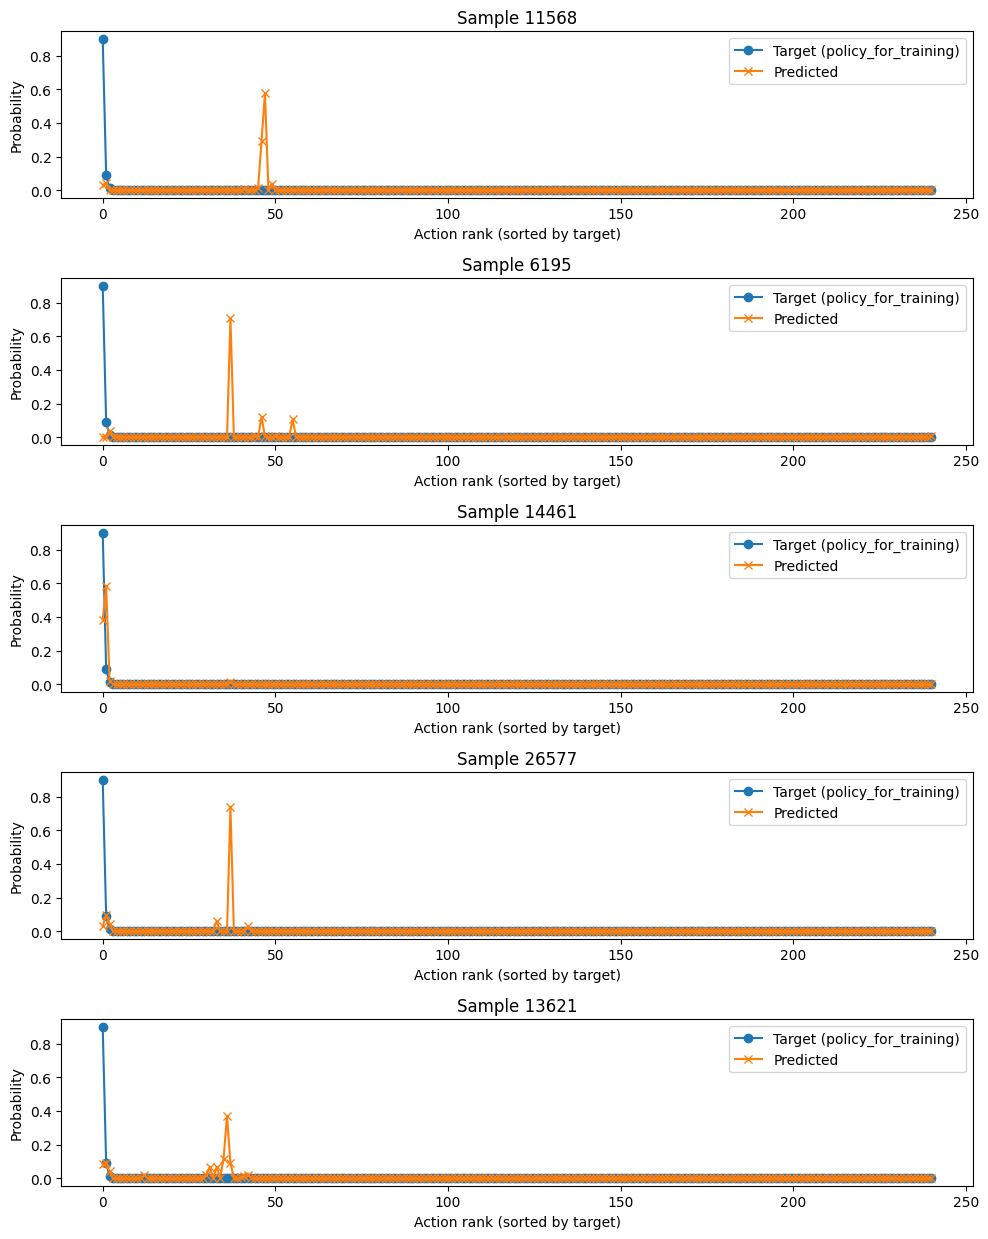

In [39]:
def plot_policy_overlap(y_true, y_pred, n_samples=5):
    idxs = np.random.choice(len(y_true), size=n_samples, replace=False)
    fig, axes = plt.subplots(n_samples, 1, figsize=(10, 2.5*n_samples))

    if n_samples == 1:
        axes = [axes]

    for ax, idx in zip(axes, idxs):
        p_true = y_true[idx]
        p_pred = y_pred[idx]

        # sort by target probs
        order = np.argsort(p_true)[::-1]
        ax.plot(p_true[order], label="Target (policy_for_training)", marker="o")
        ax.plot(p_pred[order], label="Predicted", marker="x")
        ax.set_title(f"Sample {idx}")
        ax.set_xlabel("Action rank (sorted by target)")
        ax.set_ylabel("Probability")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Example usage:
preds = model.predict([x1, x2, x3, mask], verbose=0)
y_pred_policy = preds["output"]
plot_policy_overlap(y_policy, y_pred_policy, n_samples=5)


In [40]:




# --- 1. Run predictions ---
preds = model.predict([x1, x2, x3, mask], verbose=0)
y_pred_policy = preds["output"]
y_pred_value = preds["value_output"].flatten()

# --- 2. Policy evaluation ---
y_true_policy = np.argmax(y_policy, axis=1)
y_hat_policy = np.argmax(y_pred_policy, axis=1)

acc = accuracy_score(y_true_policy, y_hat_policy)
print(f"Policy head accuracy (top-1 match): {acc:.3f}")

# --- 3. Safe JS divergence ---
def safe_js_div(p_true, p_pred, eps=1e-8):
    t = np.array(p_true, dtype=np.float64) + eps
    p = np.array(p_pred, dtype=np.float64) + eps
    t /= t.sum()
    p /= p.sum()
    return jensenshannon(t, p)

js_divs = [safe_js_div(y_policy[i], y_pred_policy[i]) for i in range(len(y_policy))]
avg_js = float(np.mean(js_divs))
print(f"Average JS divergence (policy dist vs pred): {avg_js:.4f}")

# --- 4. Top-k overlap ---
def top_k_overlap(y_true, y_pred, k=3):
    correct = 0
    for t, p in zip(y_true, y_pred):
        top_t = np.argsort(t)[-k:]
        top_p = np.argsort(p)[-k:]
        if any(a in top_t for a in top_p):
            correct += 1
    return correct / len(y_true)

for k in [1, 3, 5]:
    overlap = top_k_overlap(y_policy, y_pred_policy, k=k)
    print(f"Top-{k} overlap: {overlap:.3f}")


Policy head accuracy (top-1 match): 0.307
Average JS divergence (policy dist vs pred): 0.5878
Average JS divergence (policy dist vs pred): 0.5878
Top-1 overlap: 0.307
Top-1 overlap: 0.307
Top-3 overlap: 0.827
Top-3 overlap: 0.827
Top-5 overlap: 0.938
Top-5 overlap: 0.938


Policy head accuracy (top-1 match): 0.307


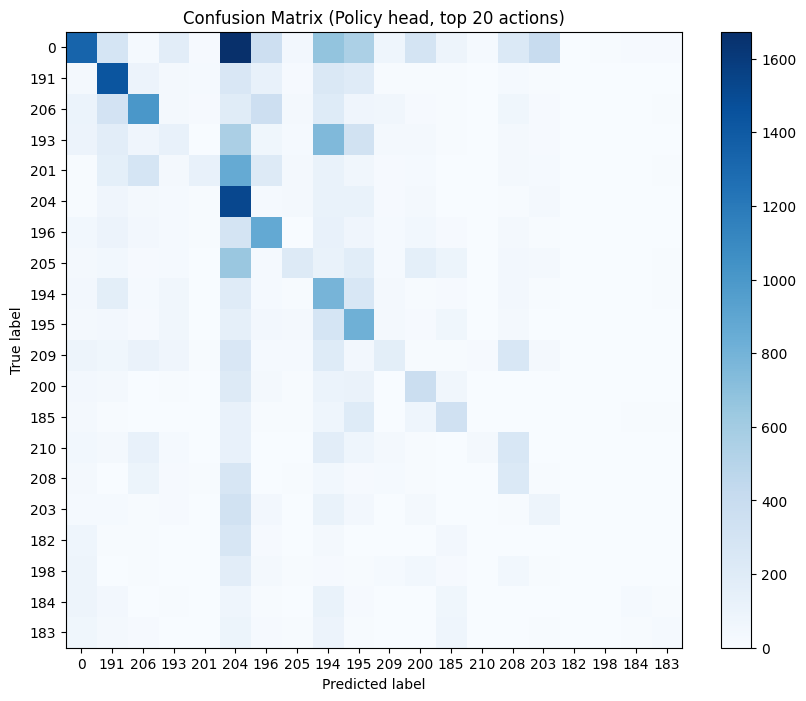


Greedy accuracy per top action:


,action,n_samples,accuracy
0,0,6687,0.199492
1,191,2651,0.541305
2,206,2632,0.381459
3,193,2448,0.050245
4,201,2213,0.054677
5,204,2209,0.689000
6,196,1897,0.459146
7,205,1813,0.118036
8,194,1778,0.441507
9,195,1749,0.468268


Value head correlation: 0.782 (p=0.00e+00)


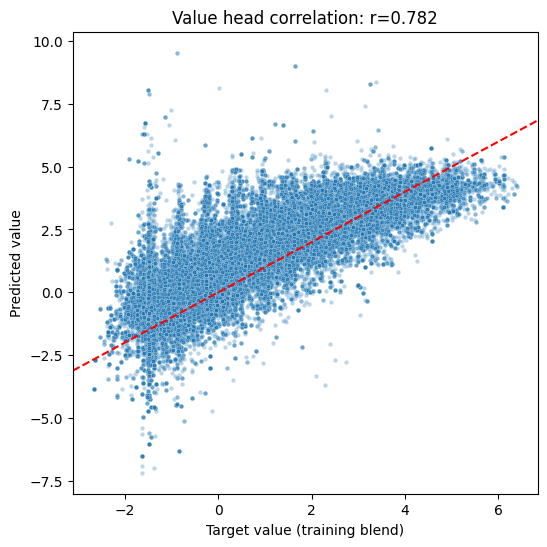

In [ ]:


# === Run predictions on the whole dataset (or validation split) ===
preds = model.predict([x1, x2, x3, mask], verbose=0)
y_pred_policy = preds["output"]
y_pred_value = preds["value_output"].flatten()

# === Policy evaluation ===
y_true_policy = np.argmax(y_policy, axis=1)
y_hat_policy = np.argmax(y_pred_policy, axis=1)

acc = accuracy_score(y_true_policy, y_hat_policy)
print(f"Policy head accuracy (top-1 match): {acc:.3f}")

# === Restrict confusion matrix to top-N most common actions ===
N = 20  # change as needed
counts = pd.Series(y_true_policy).value_counts()
top_actions = counts.index[:N].tolist()

mask_top = np.isin(y_true_policy, top_actions)
cm = confusion_matrix(
    y_true_policy[mask_top],
    y_hat_policy[mask_top],
    labels=top_actions
)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_actions)
disp.plot(include_values=False, cmap="Blues", ax=ax, colorbar=True)
ax.set_title(f"Confusion Matrix (Policy head, top {N} actions)")
plt.show()

# === Per-action greedy accuracy for top-N actions ===
action_acc = []
for act in top_actions:
    mask_act = (y_true_policy == act)
    n_total = mask_act.sum()
    if n_total > 0:
        n_correct = (y_hat_policy[mask_act] == act).sum()
        action_acc.append({
            "action": act,
            "n_samples": n_total,
            "accuracy": n_correct / n_total
        })

acc_df = pd.DataFrame(action_acc).sort_values("n_samples", ascending=False)

print("\nGreedy accuracy per top action:")
print(acc_df.head(10))  # show top-10 for readability

# === Value evaluation ===
corr, pval = pearsonr(y_value, y_pred_value)
print(f"Value head correlation: {corr:.3f} (p={pval:.2e})")

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_value, y=y_pred_value, alpha=0.3, s=10)
plt.xlabel("Target value (training blend)")
plt.ylabel("Predicted value")
plt.title(f"Value head correlation: r={corr:.3f}")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.show()



Correlation with heuristic: 0.782
Correlation with return:    0.607


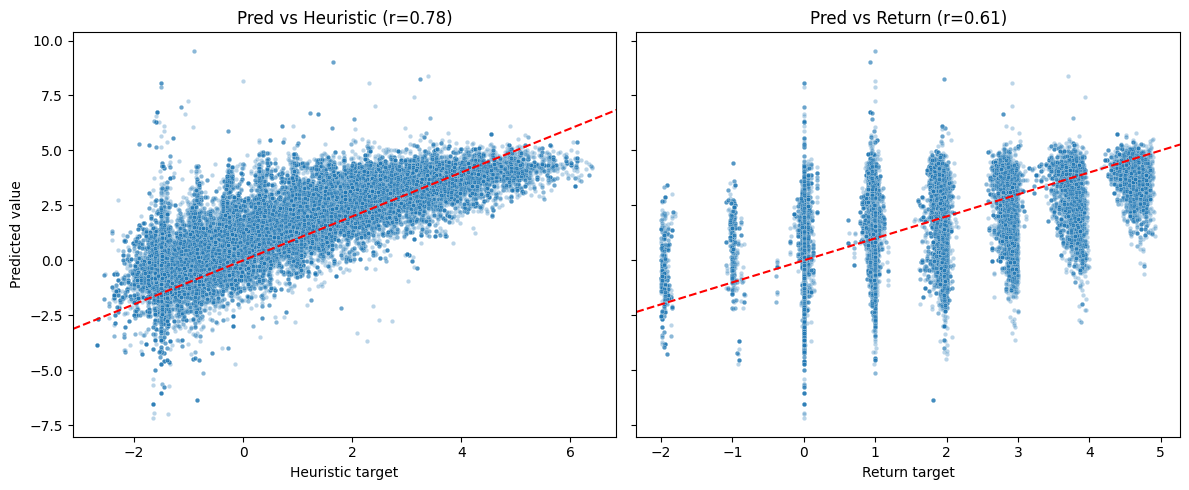

In [42]:
def plot_value_comparison(df, y_pred_value):
    """
    Compare predicted values against heuristic and returns.
    Shows scatterplots + correlation coefficients.
    """
    heuristic = df["scaled_heuristic_return"].astype(np.float32).fillna(0.0).values
    returns = df["return"].astype(np.float32).fillna(0.0).values

    # === Correlations ===
    corr_h, _ = pearsonr(heuristic, y_pred_value)
    corr_r, _ = pearsonr(returns, y_pred_value)
    print(f"Correlation with heuristic: {corr_h:.3f}")
    print(f"Correlation with return:    {corr_r:.3f}")

    # === Scatterplots ===
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.scatterplot(x=heuristic, y=y_pred_value, alpha=0.3, s=10, ax=axes[0])
    axes[0].set_xlabel("Heuristic target")
    axes[0].set_ylabel("Predicted value")
    axes[0].set_title(f"Pred vs Heuristic (r={corr_h:.2f})")
    axes[0].axline((0, 0), slope=1, color="red", linestyle="--")

    sns.scatterplot(x=returns, y=y_pred_value, alpha=0.3, s=10, ax=axes[1])
    axes[1].set_xlabel("Return target")
    axes[1].set_ylabel("Predicted value")
    axes[1].set_title(f"Pred vs Return (r={corr_r:.2f})")
    axes[1].axline((0, 0), slope=1, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()

plot_value_comparison(rl_df, y_pred_value)


## Evaluate player performance on a tournament

In [43]:
# === Create a player with Keras models ===
rl_player = pc.RLModelBasedCatanPlayer(
    name="RL Model Player",
    persona=f"A Catan player that plays based on a trained reinforcement learning model for phase {args.phase_to_train}"
)

# === Load the freshly trained model, set explore to false to always take 'best' action ===
if args.phase_to_train == 'SETUP':
    rl_player.rl_model_for_setup_phase.model = load_model(f"{args.local_directory_for_model}{args.model_name_on_local}", safe_mode=False)
    rl_player.rl_model_for_setup_phase.explore = False
elif args.phase_to_train == 'TRADE':
    rl_player.rl_model_for_trade_response.model = load_model(f"{args.local_directory_for_model}{args.model_name_on_local}", safe_mode=False)
    rl_player.rl_model_for_trade_response.explore = False
elif args.phase_to_train == 'GAMEPLAY':
    rl_player.rl_model_for_gameplay_phase.model = load_model(f"{args.local_directory_for_model}{args.model_name_on_local}", safe_mode=False)
    rl_player.rl_model_for_gameplay_phase.explore = False
else:
    print('Using RL model with default models for tournament')

# === Create a list of players for the evaluation tournament ===
players = pc.default_players.copy() # play against 'heuristic' players
players[0] = rl_player # make the first player the player with the trained model

# === Run evaluation tournament ===
tr = pc.Tournament(no_games_in_tournament=args.number_of_games_in_evaluation_tournament)
tr.verbose = False
overall_tournament_points, overall_victory_points, overall_rounds = tr.tournament(players)
tr.print_tournament_results(overall_tournament_points, overall_victory_points, overall_rounds, players)

c:\Users\nly99857\OneDrive - Philips\SW Projects\PyCatan\venvs\env_pycatan\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Results for game nr. 1:
Order of players for this game: RL Model Player, Hall 9000, Miss Minutes, C-3PO

Player      		Results		Points		Rounds
RL Model Player		10.00		8.00		10
Hall 9000		0.00		3.00		10
Miss Minutes		3.50		4.00		10
C-3PO		3.50		4.00		10

Results for game nr. 2:
Order of players for this game: RL Model Player, Hall 9000, C-3PO, Miss Minutes

Player      		Results		Points		Rounds
RL Model Player		10.00		8.00		18
Hall 9000		2.00		6.00		18
Miss Minutes		5.00		7.00		18
C-3PO		0.00		2.00		18

Results for game nr. 2:
Order of players for this game: RL Model Player, Hall 9000, C-3PO, Miss Minutes

Player      		Results		Points		Rounds
RL Model Player		10.00		8.00		18
Hall 9000		2.00		6.00		18
Miss Minutes		5.00		7.00		18
C-3PO		0.00		2.00		18

Results for game nr. 3:
Order of players for this game: RL Model Player, Miss Minutes, Hall 9000, C-3PO

Player      		Results		Points		Rounds
RL Model Player		1.00		3.00		13
Hall 9000		10.00		8.00		13
Miss Minutes		5.00		4.00		13
C-3PO	